In [1]:
import pandas as pd

df = pd.read_csv('spotify-tracks-dataset.csv')

print(df.head())

   Unnamed: 0.1  Unnamed: 0                track_id                 artists  \
0             0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1             1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2             2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3             3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4             4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       1496

In [2]:
print(df.shape)
print(df.info())

(114000, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrum

In [3]:
df = df.dropna()
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      113999 non-null  int64  
 1   Unnamed: 0        113999 non-null  int64  
 2   track_id          113999 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        113999 non-null  int64  
 7   duration_ms       113999 non-null  int64  
 8   explicit          113999 non-null  bool   
 9   danceability      113999 non-null  float64
 10  energy            113999 non-null  float64
 11  key               113999 non-null  int64  
 12  loudness          113999 non-null  float64
 13  mode              113999 non-null  int64  
 14  speechiness       113999 non-null  float64
 15  acousticness      113999 non-null  float64
 16  instrumentalness  113999 

In [4]:
track = df['track_genre'].value_counts()
print(track)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
turkish        1000
trip-hop       1000
world-music    1000
k-pop           999
Name: count, Length: 114, dtype: int64


In [5]:
features = df[['danceability',
    'energy',
    'valence',
    'tempo',
    'loudness',
    'acousticness',
    'instrumentalness',
    'speechiness',]]

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(features)

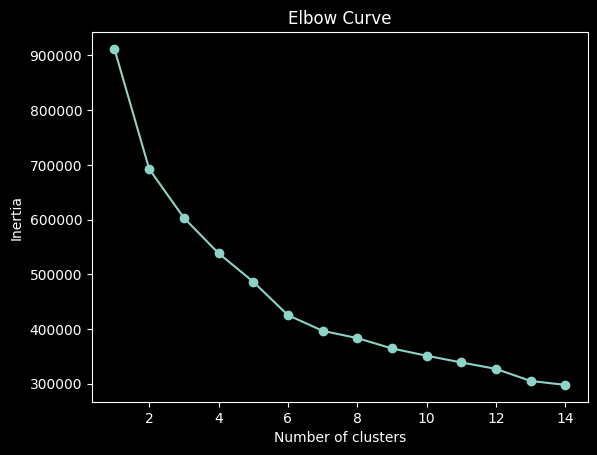

In [13]:
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans_test.fit(X)
    inertias.append(kmeans_test.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=7, random_state=0, n_init='auto').fit(X)
df['cluster'] = kmeans.labels_

print(df.groupby('cluster')[['danceability',
                             'energy',
                             'valence',
                             'tempo',
                             'loudness',
                             'acousticness',
                             'instrumentalness',
                             'speechiness']].mean())

         danceability    energy   valence       tempo   loudness  \
cluster                                                            
0            0.471170  0.816288  0.489675  163.647701  -5.300677   
1            0.710870  0.729529  0.735497  116.618344  -6.404938   
2            0.526475  0.364191  0.399842  114.115475 -10.895603   
3            0.342967  0.176171  0.181670  102.760006 -21.234724   
4            0.583664  0.744947  0.337281  126.764113  -8.420238   
5            0.649865  0.643396  0.506578  114.507755  -8.758555   
6            0.528042  0.752955  0.324855  110.065536  -6.046283   

         acousticness  instrumentalness  speechiness  
cluster                                               
0            0.120638          0.033926     0.094958  
1            0.226816          0.019820     0.078280  
2            0.717371          0.030565     0.049047  
3            0.860901          0.792473     0.050307  
4            0.111805          0.794475     0.070429  
5 

In [15]:
df['cluster_name'] = df['cluster'].map({0: 'High Tempo',
                                        1: 'Happy Vibes',
                                        2: 'Acoustic Chill',
                                        3: 'Sad Instrumental',
                                        4: 'Dark Electronic',
                                        5: 'Hip-Hop',
                                        6: 'Melancholic',})

df[['track_name', 'artists', 'cluster_name']].head(10)

,track_name,artists,cluster_name
0,Comedy,Gen Hoshino,Happy Vibes
1,Ghost - Acoustic,Ben Woodward,Acoustic Chill
2,To Begin Again,Ingrid Michaelson;ZAYN,Melancholic
3,Can't Help Falling In Love,Kina Grannis,Acoustic Chill
4,Hold On,Chord Overstreet,Acoustic Chill
5,Days I Will Remember,Tyrone Wells,Happy Vibes
6,Say Something,A Great Big World;Christina Aguilera,Acoustic Chill
7,I'm Yours,Jason Mraz,Happy Vibes
8,Lucky,Jason Mraz;Colbie Caillat,Happy Vibes
9,Hunger,Ross Copperman,Melancholic


In [16]:
def song_search(song, artists):
    result = df[df['track_name'].str.contains(song, na=False) & df['artists'].str.contains(artists, na=False)]
    result = result.drop_duplicates(subset=['track_name', 'artists'])
    result = result [['track_name', 'artists', 'cluster_name', 'energy', 'tempo', 'valence', 'danceability', 'acousticness',]]
    return result

print(song_search("Paranoid", "Black Sabbath"))

                       track_name        artists cluster_name  energy  \
47105  Paranoid (2009 - Remaster)  Black Sabbath   High Tempo   0.685   
47457  Paranoid (2012 - Remaster)  Black Sabbath   High Tempo   0.647   

         tempo  valence  danceability  acousticness  
47105  162.780    0.328         0.423      0.000063  
47457  163.047    0.409         0.415      0.000041  


In [18]:
def get_similar (cluster):
    similar = df[df['cluster_name'] == cluster]
    similar = similar.sample(n=5)
    similar = similar[['track_name', 'artists', 'cluster_name', 'energy', 'tempo', 'valence', 'danceability', 'acousticness',]]
    return similar

print(get_similar('High Tempo'))

                                         track_name          artists  \
85434                                         Ciúme  Ultraje a Rigor   
47238                              Caught Up In You       38 Special   
50621                      La Huella Del Depredador           Carajo   
92254  サブウェイ特急 - Live at 日本武道館'04 - Remastered 2022   Eikichi Yazawa   
60322                           Everytime I See You            E-Dee   

      cluster_name  energy    tempo  valence  danceability  acousticness  
85434   High Tempo   0.886  169.132    0.656         0.368      0.005880  
47238   High Tempo   0.787  130.693    0.889         0.361      0.019700  
50621   High Tempo   0.929  160.877    0.547         0.460      0.000687  
92254   High Tempo   0.916  142.014    0.517         0.482      0.001310  
60322   High Tempo   0.686  129.378    0.624         0.521      0.014100  


In [19]:
def song_analyze (song, artists):
    search = song_search(song, artists)
    cluster = search['cluster_name'].iloc[0]
    similar = get_similar(cluster)
    return search, similar

track_info, similar = song_analyze("Paranoid", "Black Sabbath")
print("Track info:")
print(track_info)
print("\nSimilar tracks:")
print(similar)

Track info:
                       track_name        artists cluster_name  energy  \
47105  Paranoid (2009 - Remaster)  Black Sabbath   High Tempo   0.685   
47457  Paranoid (2012 - Remaster)  Black Sabbath   High Tempo   0.647   

         tempo  valence  danceability  acousticness  
47105  162.780    0.328         0.423      0.000063  
47457  163.047    0.409         0.415      0.000041  

Similar tracks:
                      track_name                      artists cluster_name  \
89395                   Se Menea          Don Omar;Nio Garcia   High Tempo   
113609                 I See You    Chris Tomlin;Brandon Lake   High Tempo   
88738             Non Ti Dico No    Boomdabash;Loredana Bertè   High Tempo   
107630            Love In Motion  ICEHOUSE;Christina Amphlett   High Tempo   
78363   Kreisligahelden sind wir              Kreisligahelden   High Tempo   

        energy    tempo  valence  danceability  acousticness  
89395    0.839  179.936    0.932         0.711        0.0

In [20]:
import joblib
joblib.dump(kmeans, 'kmeans.pkl')
joblib.dump(scaler, 'scaler.pkl')

df.to_csv('tracks_with_clusters.csv', index=False)